# 02 Retrieval Benchmark

Notebook này chỉ làm retrieval benchmark:

- Load RAGAS-generated benchmark questions.
- So sánh `bm25`, `vector`, `hybrid`, `hybrid_rrf`, `hybrid_rrf_mmr`.
- Lưu contexts/citations cho từng method vào `reports/retrieval_evaluation.json`.

Notebook này **chưa chọn phương pháp cuối cùng**. Notebook 03 sẽ dùng kết quả retrieval + RAGAS answer evaluation để chọn final method.

In [1]:
from pathlib import Path
from dataclasses import asdict, dataclass, field
from typing import Any
from collections import defaultdict
import hashlib
import html
import json
import math
import os
import re

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from rank_bm25 import BM25Okapi
from ragas import evaluate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as normalize_sparse


@dataclass
class LegalDocument:
    id: str
    title: str | None = None
    so_ky_hieu: str | None = None
    ngay_ban_hanh: str | None = None
    loai_van_ban: str | None = None
    ngay_co_hieu_luc: str | None = None
    ngay_het_hieu_luc: str | None = None
    nguon_thu_thap: str | None = None
    ngay_dang_cong_bao: str | None = None
    nganh: str | None = None
    linh_vuc: str | None = None
    co_quan_ban_hanh: str | None = None
    chuc_danh: str | None = None
    nguoi_ky: str | None = None
    pham_vi: str | None = None
    thong_tin_ap_dung: str | None = None
    tinh_trang_hieu_luc: str | None = None
    content_html: str | None = None
    content_text: str | None = None
    source_url: str | None = None
    raw_metadata: dict[str, Any] = field(default_factory=dict)


@dataclass
class LegalChunk:
    chunk_id: str
    doc_id: str
    title: str
    text: str
    article: str | None = None
    source_url: str | None = None
    doc_type: str | None = None
    effective_date: str | None = None
    metadata: dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> dict[str, Any]:
        return asdict(self)


@dataclass
class SearchResult:
    chunk: LegalChunk
    score: float
    method: str
    rank: int | None = None


def normalize_text(text: str | None) -> str:
    text = html.unescape(text or "")
    text = re.sub(r"<script.*?</script>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<style.*?</style>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_for_match(text: str | None) -> str:
    return normalize_text(text).lower()


def tokenize_vi(text: str | None) -> list[str]:
    return re.findall(r"\w+", normalize_for_match(text))


def load_documents_from_jsonl(path: str) -> list[LegalDocument]:
    documents = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                documents.append(LegalDocument(**json.loads(line)))
    return documents


ARTICLE_PATTERN = re.compile(r"(?=(?:Điều|ĐIỀU)\s+\d+[a-zA-Z]?\.)")


def split_by_article_or_window(text: str, max_words: int = 260, overlap: int = 40) -> list[tuple[str | None, str]]:
    text = normalize_text(text)
    if not text:
        return []
    parts = [part.strip() for part in ARTICLE_PATTERN.split(text) if part.strip()]
    if len(parts) > 1:
        chunks = []
        for part in parts:
            article_match = re.match(r"(Điều\s+\d+[a-zA-Z]?)\.", part, flags=re.IGNORECASE)
            chunks.append((article_match.group(1) if article_match else None, part))
        return chunks
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append((None, " ".join(words[start:end])))
        if end == len(words):
            break
        start = max(0, end - overlap)
    return chunks


def chunk_document(document: LegalDocument, max_words: int = 260, overlap: int = 40) -> list[LegalChunk]:
    chunks = []
    source_text = document.content_text or document.content_html or ""
    for idx, (article, text) in enumerate(split_by_article_or_window(source_text, max_words, overlap)):
        if len(text.split()) < 30:
            continue
        chunks.append(
            LegalChunk(
                chunk_id=f"{document.id}_{idx}",
                doc_id=document.id,
                title=document.title or "",
                text=text,
                article=article,
                source_url=document.source_url,
                doc_type=document.loai_van_ban,
                effective_date=document.ngay_co_hieu_luc,
                metadata={
                    "so_ky_hieu": document.so_ky_hieu,
                    "agency": document.co_quan_ban_hanh,
                    "status": document.tinh_trang_hieu_luc,
                },
            )
        )
    return chunks


def chunk_documents(documents: list[LegalDocument], max_words: int = 260, overlap: int = 40) -> list[LegalChunk]:
    chunks = []
    for document in documents:
        chunks.extend(chunk_document(document, max_words, overlap))
    return chunks


CORPUS_PATH = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RAGAS_QUESTIONS_JSON = REPORTS_DIR / "ragas_questions.json"
RAGAS_QUESTIONS_MD = REPORTS_DIR / "ragas_questions.md"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RETRIEVAL_MD = REPORTS_DIR / "retrieval_evaluation.md"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"

DEFAULT_MODEL = "gemini-3.1-flash-lite"
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
TOP_K = 5
CHUNK_MAX_WORDS = 260
CHUNK_OVERLAP_WORDS = 40
BENCHMARK_MAX_CHUNKS = None
METHODS = ["bm25", "vector", "hybrid", "hybrid_rrf", "hybrid_rrf_mmr"]

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
load_dotenv(PROJECT_ROOT / ".env")


def gemini_keys():
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys, seen = [], set()
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in seen:
                keys.append(key)
                seen.add(key)
    return keys


def load_ragas_questions():
    if not RAGAS_QUESTIONS_JSON.exists():
        raise FileNotFoundError("Missing reports/ragas_questions.json. Run the RAGAS TestsetGenerator cell first.")
    payload = json.loads(RAGAS_QUESTIONS_JSON.read_text(encoding="utf-8"))
    if not payload.get("generated_with_ragas"):
        raise ValueError("reports/ragas_questions.json must come from RAGAS TestsetGenerator.")
    items = payload.get("items") or []
    if len(items) < 30:
        raise ValueError("RAGAS benchmark must contain at least 30 accepted questions.")
    return payload, items


def save_ragas_questions(items):
    payload = {
        "generated_with_ragas": True,
        "candidate_target": 40,
        "accepted_count": len(items),
        "items": items,
    }
    RAGAS_QUESTIONS_JSON.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    lines = [
        "# RAGAS Questions",
        "",
        "- Generated with RAGAS TestsetGenerator: `True`",
        f"- Accepted questions: `{len(items)}`",
        "",
        "| ID | Topic | Source | Question |",
        "|---|---|---|---|",
    ]
    for item in items:
        lines.append(f"| {item['id']} | {item['topic']} | {item['source']} | {item['question']} |")
    RAGAS_QUESTIONS_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return payload


def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. RAGAS Questions

Benchmark chính dùng câu hỏi sinh bởi RAGAS TestsetGenerator. Nếu artifact chưa có, cell này mới gọi Gemini để tạo và freeze lại.

In [2]:
def generate_ragas_questions():
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required to generate RAGAS benchmark questions.")
    os.environ.setdefault("GOOGLE_API_KEY", keys[0])

    from langchain_core.documents import Document
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
    from ragas.embeddings.base import LangchainEmbeddingsWrapper
    from ragas.llms.base import LangchainLLMWrapper
    from ragas.testset import TestsetGenerator
    from ragas.testset.persona import Persona
    from ragas.testset.synthesizers.single_hop.specific import SingleHopSpecificQuerySynthesizer

    chunks = [chunk for chunk in chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH)), max_words=CHUNK_MAX_WORDS, overlap=CHUNK_OVERLAP_WORDS) if len(chunk.text) >= 400]
    stride = max(1, len(chunks) // 12)
    source_docs = [
        Document(page_content=chunk.text[:600], metadata={"doc_id": chunk.doc_id, "title": chunk.title, "chunk_id": chunk.chunk_id})
        for chunk in chunks[::stride][:12]
    ]
    llm_context = "Generate Vietnamese labor-law benchmark questions and reference answers from the provided legal context."
    llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model=DEFAULT_MODEL, google_api_key=keys[0], temperature=0))
    embeddings = LangchainEmbeddingsWrapper(GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=keys[0]))
    personas = [
        Persona(name="Worker", role_description="An employee asking about labor-law rights."),
        Persona(name="Employer", role_description="An HR manager checking labor-law compliance."),
        Persona(name="LegalAdvisor", role_description="A legal advisor reviewing labor-law questions."),
    ]
    generator = TestsetGenerator(llm=llm, embedding_model=embeddings, persona_list=personas, llm_context=llm_context)
    generated = generator.generate_with_langchain_docs(
        source_docs,
        testset_size=40,
        query_distribution=[(SingleHopSpecificQuerySynthesizer(llm=llm, llm_context=llm_context), 1.0)],
        raise_exceptions=False,
    )
    rows = []
    for idx, row in generated.to_pandas().iterrows():
        question = str(row.get("user_input") or row.get("question") or "").strip()
        reference = str(row.get("reference") or row.get("reference_contexts") or "").strip()
        if question and len(question.split()) >= 5:
            rows.append({
                "id": f"ragas_{idx + 1:03d}",
                "question": question,
                "reference": reference or question,
                "topic": str(row.get("synthesizer_name") or "ragas_generated"),
                "source": "ragas_generator",
            })
    if len(rows) < 30:
        raise RuntimeError(f"RAGAS generated only {len(rows)} valid questions.")
    return save_ragas_questions(rows[:30]), rows[:30]


try:
    question_meta, questions = load_ragas_questions()
except FileNotFoundError:
    question_meta, questions = generate_ragas_questions()

pd.DataFrame([{k: question_meta.get(k) for k in ["generated_with_ragas", "candidate_target", "accepted_count"]}])


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


In [3]:
pd.DataFrame(questions)[["id", "topic", "source", "question"]].head(12)

,id,topic,source,question
0,ragas_001,single_hop_specific_query_synthesizer,ragas_generator,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...
1,ragas_002,single_hop_specific_query_synthesizer,ragas_generator,Quy trình giải thể Xí nghiệp liên doanh được q...
2,ragas_003,single_hop_specific_query_synthesizer,ragas_generator,Khi nào thì hội đồng quản trị của xí nghiệp li...
3,ragas_004,single_hop_specific_query_synthesizer,ragas_generator,CHƯƠNG VI nói về cái gì vậy ạ?
4,ragas_005,single_hop_specific_query_synthesizer,ragas_generator,anh oi cho hoi cai Nghị định số 103/1999/NĐ-CP...
5,ragas_006,single_hop_specific_query_synthesizer,ragas_generator,Theo Nghị định số 103/1999/NĐ-CP của Chính phủ...
6,ragas_007,single_hop_specific_query_synthesizer,ragas_generator,Nghị định số 103/1999/NĐ-CP quy định gì về việ...
7,ragas_008,single_hop_specific_query_synthesizer,ragas_generator,Khi các bên lập phương án dựa trên hướng phát ...
8,ragas_009,single_hop_specific_query_synthesizer,ragas_generator,UBND TỈNH LÂM ĐỒNG đã đánh giá như thế nào về ...
9,ragas_010,single_hop_specific_query_synthesizer,ragas_generator,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình..."


## 2. Retrieval Methods

Vector retrieval dùng sparse TF-IDF cosine similarity để tránh convert toàn bộ corpus sang dense matrix. Điều này giữ notebook chạy được với full corpus.

In [4]:
def chunk_text(chunk):
    return f"{chunk.title} {chunk.text}"


class NotebookRetriever:
    def __init__(self, chunks):
        self.chunks = chunks
        self.texts = [chunk_text(chunk) for chunk in chunks]
        self.bm25 = BM25Okapi([tokenize_vi(text) for text in self.texts])
        self.vectorizer = TfidfVectorizer(max_features=384, ngram_range=(1, 2))
        self.embeddings = normalize_sparse(self.vectorizer.fit_transform(self.texts), norm="l2", copy=False)

    def retrieve(self, query, method, top_k=TOP_K):
        sparse = self.retrieve_bm25(query, max(30, top_k * 5))
        vector = self.retrieve_vector(query, max(30, top_k * 5))
        if method == "bm25":
            return sparse[:top_k]
        if method == "vector":
            return vector[:top_k]
        if method == "hybrid":
            return self.weighted_hybrid(sparse, vector, top_k)
        if method == "hybrid_rrf":
            return self.rrf([sparse, vector], top_k)
        if method == "hybrid_rrf_mmr":
            return self.mmr(self.rrf([sparse, vector], max(20, top_k * 4)), top_k)
        raise ValueError(method)

    def retrieve_bm25(self, query, top_k):
        scores = self.bm25.get_scores(tokenize_vi(query))
        top_indices = np.argpartition(scores, -min(top_k, len(scores)))[-top_k:]
        indices = sorted(top_indices, key=lambda idx: scores[idx], reverse=True)
        return [SearchResult(self.chunks[int(idx)], float(scores[int(idx)]), "bm25", rank) for rank, idx in enumerate(indices, start=1)]

    def retrieve_vector(self, query, top_k):
        query_vector = normalize_sparse(self.vectorizer.transform([query]), norm="l2", copy=False)
        scores = (self.embeddings @ query_vector.T).toarray().ravel()
        top_indices = np.argpartition(scores, -min(top_k, len(scores)))[-top_k:]
        indices = sorted(top_indices, key=lambda idx: scores[idx], reverse=True)
        return [SearchResult(self.chunks[int(idx)], float(scores[int(idx)]), "vector", rank) for rank, idx in enumerate(indices, start=1)]

    @staticmethod
    def minmax(results):
        if not results:
            return {}
        scores = [result.score for result in results]
        low, high = min(scores), max(scores)
        if high == low:
            return {result.chunk.chunk_id: 1.0 for result in results}
        return {result.chunk.chunk_id: (result.score - low) / (high - low) for result in results}

    def weighted_hybrid(self, sparse, vector, top_k):
        sparse_scores = self.minmax(sparse)
        vector_scores = self.minmax(vector)
        chunks = {result.chunk.chunk_id: result.chunk for result in sparse + vector}
        scores = defaultdict(float)
        for chunk_id, score in sparse_scores.items():
            scores[chunk_id] += 0.55 * score
        for chunk_id, score in vector_scores.items():
            scores[chunk_id] += 0.45 * score
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def rrf(result_lists, top_k):
        scores, chunks = defaultdict(float), {}
        for results in result_lists:
            for rank, result in enumerate(results, start=1):
                chunks[result.chunk.chunk_id] = result.chunk
                scores[result.chunk.chunk_id] += 1.0 / (60 + rank)
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid_rrf", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def mmr(results, top_k):
        selected, seen_docs = [], set()
        for result in results:
            if result.chunk.doc_id in seen_docs and len(selected) < max(1, top_k - 1):
                continue
            selected.append(result)
            seen_docs.add(result.chunk.doc_id)
            if len(selected) == top_k:
                break
        if len(selected) < top_k:
            selected.extend(result for result in results if result not in selected)
        return [SearchResult(result.chunk, result.score, "hybrid_rrf_mmr", rank) for rank, result in enumerate(selected[:top_k], start=1)]


In [ ]:
STOPWORDS = {"cua", "cho", "cac", "mot", "nhung", "theo", "quy", "dinh", "duoc", "khong", "trong", "voi", "khi", "thi", "la", "ve", "va"}


def content_tokens(text):
    return {token for token in tokenize_vi(normalize_for_match(text)) if len(token) > 2 and token not in STOPWORDS}


def overlap_score(result, item):
    expected = content_tokens(f"{item.get('reference', '')} {item.get('question', '')}")
    observed = content_tokens(chunk_text(result.chunk))
    return len(expected & observed) / max(len(expected), 1)


def local_metrics(results, item):
    gains = [overlap_score(result, item) for result in results[:TOP_K]]
    dcg = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(gains))
    ideal = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(sorted(gains, reverse=True)))
    first = next((idx for idx, gain in enumerate(gains, start=1) if gain >= 0.12), None)
    combined = " ".join(chunk_text(result.chunk) for result in results[:TOP_K])
    target = f"{item.get('reference', '')} {item.get('question', '')}"
    recall = len(content_tokens(combined) & content_tokens(target)) / max(len(content_tokens(target)), 1)
    return {
        "recall@5": 1.0 if first else 0.0,
        "mrr": 1.0 / first if first else 0.0,
        "ndcg@5": dcg / ideal if ideal else 0.0,
        "lexical_context_precision": sum(gains) / max(len(gains), 1),
        "lexical_context_recall": recall,
        "citation_coverage": sum(bool(result.chunk.title and result.chunk.doc_id) for result in results) / max(len(results), 1),
    }


def serialize_result(result: SearchResult) -> dict:
    chunk = result.chunk
    return {
        "rank": result.rank,
        "score": result.score,
        "chunk_id": chunk.chunk_id,
        "doc_id": chunk.doc_id,
        "title": chunk.title,
        "article": chunk.article,
        "source_url": chunk.source_url,
        "doc_type": chunk.doc_type,
        "text": chunk.text,
    }


def ragas_context_scores(rows):
    from ragas.metrics._context_precision import NonLLMContextPrecisionWithReference
    from ragas.metrics._context_recall import NonLLMContextRecall

    output = {}
    for method in METHODS:
        dataset = Dataset.from_list([
            {
                "user_input": row["question"],
                "retrieved_contexts": row["contexts"],
                "reference_contexts": [row["reference"]],
                "reference": row["reference"],
            }
            for row in rows if row["method"] == method
        ])
        frame = evaluate(dataset=dataset, metrics=[NonLLMContextPrecisionWithReference(), NonLLMContextRecall()], show_progress=False).to_pandas()
        output[method] = {
            "ragas_context_precision": float(frame["non_llm_context_precision_with_reference"].mean()),
            "ragas_context_recall": float(frame["non_llm_context_recall"].mean()),
        }
    return output


def retrieval_candidate_score(row):
    cp = row.get("ragas_context_precision")
    cr = row.get("ragas_context_recall")
    if cp is None or not math.isfinite(cp):
        cp = row["lexical_context_precision"]
    if cr is None or not math.isfinite(cr):
        cr = row["lexical_context_recall"]
    return 0.30 * row["mrr"] + 0.25 * row["ndcg@5"] + 0.25 * cp + 0.20 * cr


In [6]:
chunks = chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH)), max_words=CHUNK_MAX_WORDS, overlap=CHUNK_OVERLAP_WORDS)
if BENCHMARK_MAX_CHUNKS is not None:
    chunks = chunks[:BENCHMARK_MAX_CHUNKS]
retriever = NotebookRetriever(chunks)
details, ragas_rows = [], []

for method in METHODS:
    for item in questions:
        results = retriever.retrieve(item["question"], method, TOP_K)
        contexts = [result.chunk.text for result in results]
        row = {
            "question_id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "method": method,
            "top_title": results[0].chunk.title if results else None,
            "contexts": contexts,
            "citations": [serialize_result(result) for result in results],
            **local_metrics(results, item),
        }
        details.append(row)
        ragas_rows.append(row)

ragas_scores = ragas_context_scores(ragas_rows)
summary = []
for method in METHODS:
    rows = [row for row in details if row["method"] == method]
    aggregate = {
        "method": method,
        **{metric: sum(row[metric] for row in rows) / len(rows) for metric in ["recall@5", "mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall", "citation_coverage"]},
        "ragas_context_precision": ragas_scores.get(method, {}).get("ragas_context_precision"),
        "ragas_context_recall": ragas_scores.get(method, {}).get("ragas_context_recall"),
    }
    aggregate["retrieval_candidate_score"] = retrieval_candidate_score(aggregate)
    summary.append(aggregate)

summary = sorted(summary, key=lambda row: (row["retrieval_candidate_score"], row["mrr"], row["ndcg@5"]), reverse=True)
retrieval_report = {
    "question_count": len(questions),
    "num_chunks": len(chunks),
    "methods": METHODS,
    "top_k": TOP_K,
    "chunk_max_words": CHUNK_MAX_WORDS,
    "chunk_overlap_words": CHUNK_OVERLAP_WORDS,
    "ragas_backend": "ragas_evaluate_non_llm",
    "selection_stage": "retrieval_only_no_final_method",
    "final_selection": None,
    "summary": summary,
    "details": details,
}
RETRIEVAL_JSON.write_text(json.dumps(sanitize(retrieval_report), ensure_ascii=False, indent=2), encoding="utf-8")
retrieval_df = pd.DataFrame(summary)
display(Markdown("Notebook 02 chỉ xếp hạng retrieval candidates. Final method sẽ được chọn ở notebook 03."))
retrieval_df


Notebook 02 chỉ xếp hạng retrieval candidates. Final method sẽ được chọn ở notebook 03.

,method,recall@5,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,citation_coverage,ragas_context_precision,ragas_context_recall,retrieval_candidate_score
0,hybrid,0.966667,0.966667,0.971033,0.513678,0.840638,1.0,0.0,0.0,0.532758
1,bm25,1.000000,0.975000,0.957600,0.578546,0.845141,1.0,0.0,0.0,0.531900
2,hybrid_rrf_mmr,0.966667,0.966667,0.939262,0.527128,0.845509,1.0,0.0,0.0,0.524816
3,hybrid_rrf,0.966667,0.966667,0.937824,0.530869,0.844814,1.0,0.0,0.0,0.524456
4,vector,1.000000,0.956667,0.931987,0.414802,0.709577,1.0,0.0,0.0,0.519997


## 3. Retrieval Figures and Report

### retrieval_candidate_score.png

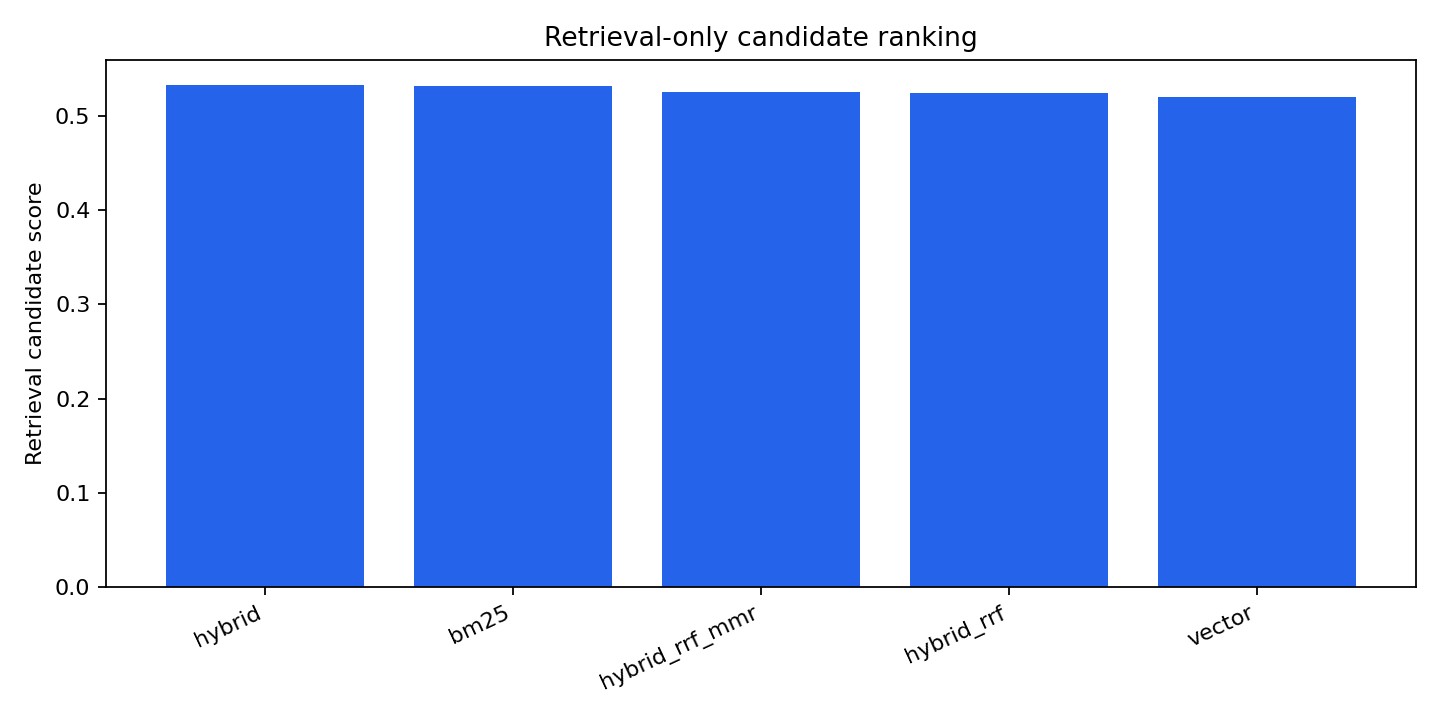

### retrieval_metric_comparison.png

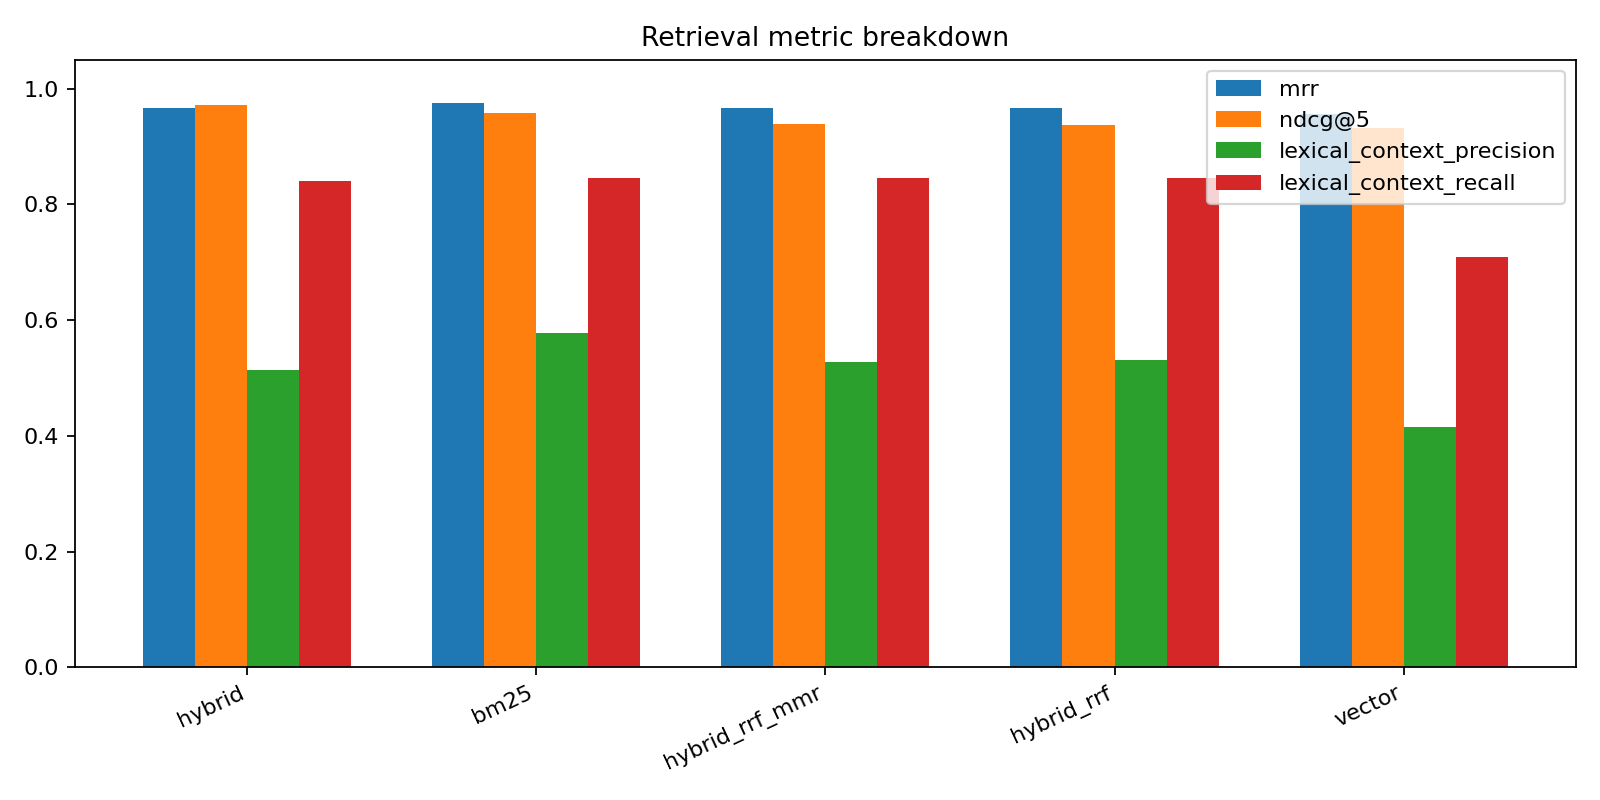

### retrieval_query_heatmap.png

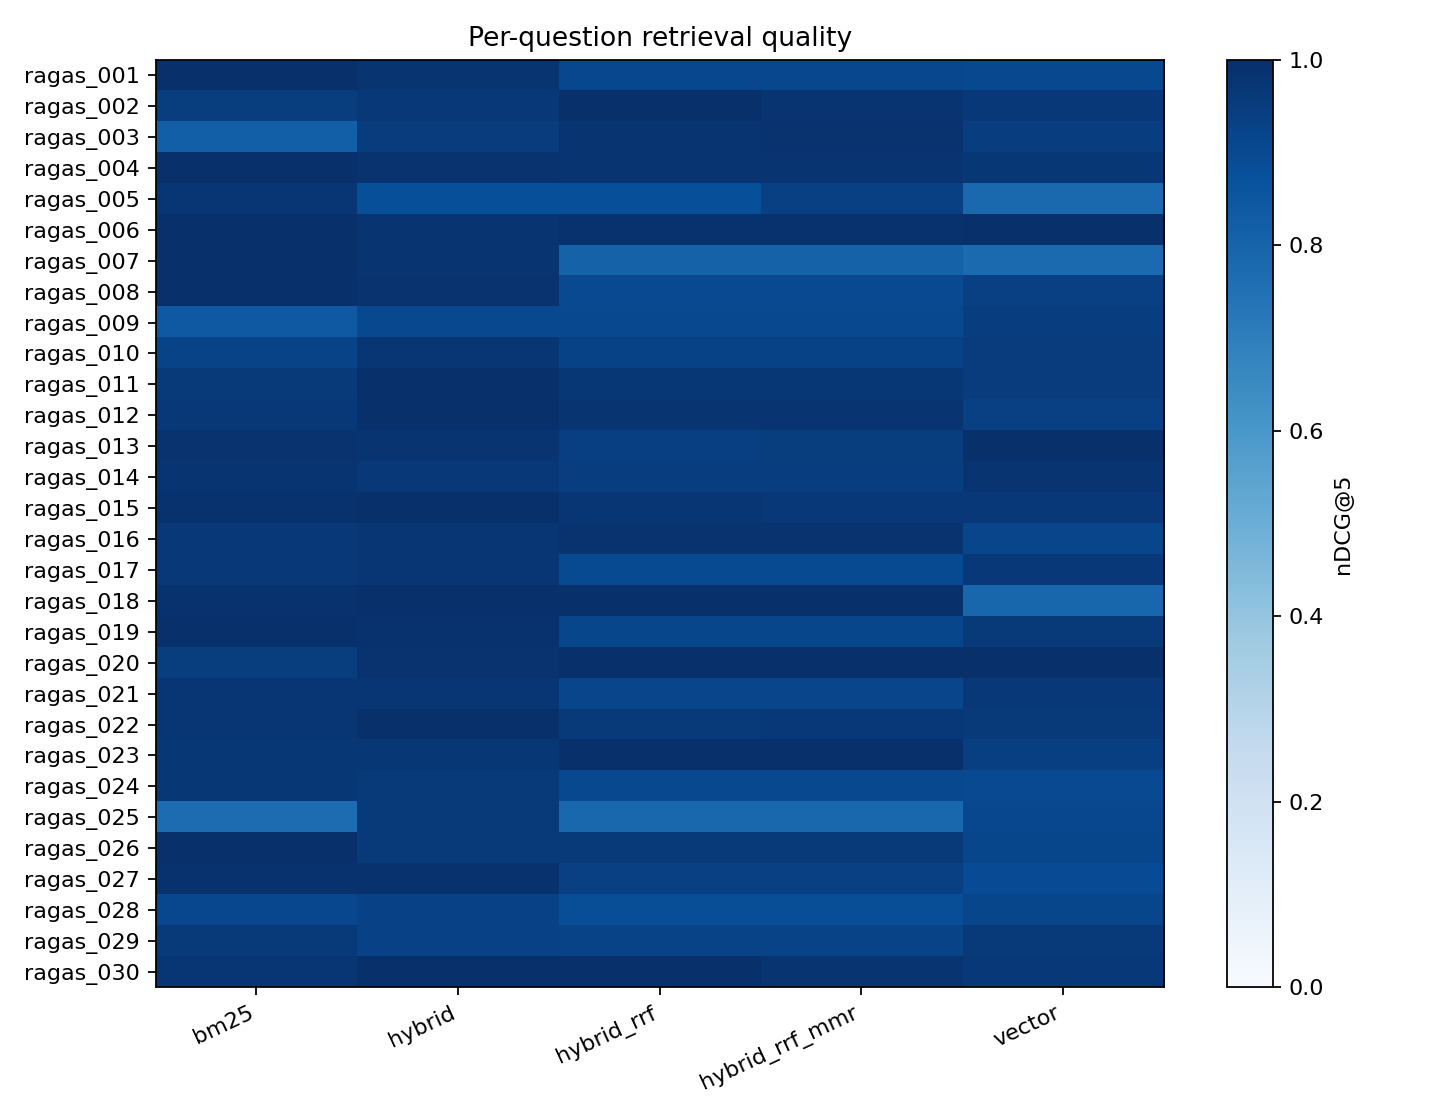

In [7]:
ordered = retrieval_df.sort_values("retrieval_candidate_score", ascending=False)
plt.figure(figsize=(9, 4.5))
plt.bar(ordered["method"], ordered["retrieval_candidate_score"], color="#2563eb")
plt.ylabel("Retrieval candidate score")
plt.title("Retrieval-only candidate ranking")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_candidate_score.png", dpi=160)
plt.close()

metric_cols = ["mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall"]
x = np.arange(len(retrieval_df["method"]))
width = 0.18
plt.figure(figsize=(10, 5))
for idx, metric in enumerate(metric_cols):
    plt.bar(x + (idx - 1.5) * width, retrieval_df[metric], width=width, label=metric)
plt.xticks(x, retrieval_df["method"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.title("Retrieval metric breakdown")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_metric_comparison.png", dpi=160)
plt.close()

details_df = pd.DataFrame(details)
pivot = details_df.pivot_table(index="question_id", columns="method", values="ndcg@5", aggfunc="mean")
plt.figure(figsize=(9, 7))
plt.imshow(pivot.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="nDCG@5")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Per-question retrieval quality")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_query_heatmap.png", dpi=160)
plt.close()

for name in ["retrieval_candidate_score.png", "retrieval_metric_comparison.png", "retrieval_query_heatmap.png"]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))


In [8]:
lines = [
    "# Retrieval Evaluation",
    "",
    f"- Question count: `{retrieval_report['question_count']}`",
    f"- Benchmark chunks: `{retrieval_report['num_chunks']}`",
    f"- RAGAS retrieval metrics backend: `{retrieval_report['ragas_backend']}`",
    "- Final method selected here: `False`",
    "- Next step: notebook 03 combines these candidates with answer/RAGAS evaluation.",
    "",
    "| Rank | Method | MRR | nDCG@5 | Lexical CP | Lexical CR | RAGAS CP | RAGAS CR | Retrieval candidate score |",
    "|---:|---|---:|---:|---:|---:|---:|---:|---:|",
]
for rank, row in enumerate(retrieval_df.to_dict("records"), start=1):
    lines.append(
        f"| {rank} | {row['method']} | {row['mrr']:.3f} | {row['ndcg@5']:.3f} | "
        f"{row['lexical_context_precision']:.3f} | {row['lexical_context_recall']:.3f} | "
        f"{row['ragas_context_precision']:.3f} | {row['ragas_context_recall']:.3f} | {row['retrieval_candidate_score']:.3f} |"
    )
lines.extend([
    "",
    "## Figures",
    "",
    "- `reports/figures/retrieval_candidate_score.png`",
    "- `reports/figures/retrieval_metric_comparison.png`",
    "- `reports/figures/retrieval_query_heatmap.png`",
    "",
])
RETRIEVAL_MD.write_text("\n".join(lines), encoding="utf-8")
Markdown("Retrieval report saved. No final method is selected in notebook 02.")


Retrieval report saved. No final method is selected in notebook 02.

In [9]:
details_df[["question_id", "method", "mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall", "top_title"]].head(30)

,question_id,method,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,top_title
0,ragas_001,bm25,1.00,0.992299,0.811111,0.981481,Hướng dẫn thi hành Quy chế lao động đối với cá...
1,ragas_002,bm25,1.00,0.948253,0.481967,0.852459,Về đẩy mạnh sắp xếp và đổi mới doanh nghiệp nh...
2,ragas_003,bm25,1.00,0.817890,0.538462,0.938462,Về việc tuyển dụng và thực hiện chế độ đãi ngộ...
3,ragas_004,bm25,1.00,1.000000,0.350000,0.750000,Về việc hướng dẫn việc làm và sử dụng sổ lao đ...
4,ragas_005,bm25,1.00,0.973743,0.337037,0.648148,Hướng dẫn một số Điều về lao động theo Nghị đị...
5,ragas_006,bm25,1.00,0.996073,0.600000,0.891304,Hướng dẫn một số Điều về lao động theo Nghị đị...
6,ragas_007,bm25,1.00,0.998157,0.589189,0.945946,Hướng dẫn một số Điều về lao động theo Nghị đị...
7,ragas_008,bm25,1.00,1.000000,0.604545,0.909091,Hướng dẫn một số Điều về lao động theo Nghị đị...
8,ragas_009,bm25,1.00,0.840882,0.542857,0.946429,"Quy định về tổ chức hoạt động văn hóa, văn ngh..."
9,ragas_010,bm25,1.00,0.925166,0.537500,0.875000,Về việc tổ chức triển khai thực hiện việc sắp ...
